In [421]:
import warnings
from IPython.display import display
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from pathlib import Path
import numpy as np
import math

warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (9,5)
plt.rcParams["axes.grid"] = True
print("Environment is ready.")


Environment is ready.


Create a list to collect model results

In [422]:
all_model_results =[]

1.1 Load the Excel dataset

In [423]:
df1 = pd.read_excel("./04_Used_Car_Prices.xlsm")
print("Dataset loaded")

Dataset loaded


1.2 Check THE dataset shape

In [424]:
print("Rows:", df1.shape[0])
print("Columns:", df1.shape[1])

Rows: 283
Columns: 10


1.3 Preview the first rows

In [425]:
display(df1.head())

,car_id,brand,fuel_type,transmission,mileage_km,car_age_years,engine_size_l,horsepower,owners_count,price_usd
0,CAR0001,Hyundai,Petrol,Automatic,"56,415.00",3,1.47,139.20,2,"37,182.35"
1,CAR0002,Hyundai,Petrol,Automatic,"154,033.00",11,1.36,163.10,2,"29,274.24"
2,CAR0003,Toyota,Hybrid,Automatic,"104,558.00",5,1.35,149.50,2,"56,221.59"
3,CAR0004,Hyundai,Diesel,Manual,"58,516.00",2,1.75,134.90,1,"47,683.85"
4,CAR0005,Kia,Petrol,Automatic,"101,497.00",7,2.40,221.10,2,"37,704.38"


1.4 Inspect column names and data types

In [426]:
column_types_1 = pd.DataFrame({
    "column": df1.columns,
    "dtype": df1.dtypes.astype(str).values
})
display(column_types_1)

,column,dtype
0,car_id,str
1,brand,str
2,fuel_type,str
3,transmission,str
4,mileage_km,float64
5,car_age_years,int64
6,engine_size_l,float64
7,horsepower,float64
8,owners_count,int64
9,price_usd,float64


1.5 Display detailed DataFrame information

In [427]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   car_id         283 non-null    str    
 1   brand          280 non-null    str    
 2   fuel_type      279 non-null    str    
 3   transmission   283 non-null    str    
 4   mileage_km     278 non-null    float64
 5   car_age_years  283 non-null    int64  
 6   engine_size_l  283 non-null    float64
 7   horsepower     279 non-null    float64
 8   owners_count   283 non-null    int64  
 9   price_usd      283 non-null    float64
dtypes: float64(4), int64(2), str(4)
memory usage: 22.2 KB


1.6 Generate descriptive statistics

In [428]:
display(df1.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_id,283,280,CAR0002,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,280,5,Hyundai,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,279,3,Petrol,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,283,2,Automatic,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage_km,278.00,NaN,NaN,NaN,"116,838.30","67,131.64","1,000.00","58,248.25","120,550.50","165,798.00","260,000.00"
car_age_years,283.00,NaN,NaN,NaN,7.47,4.64,0.00,3.00,7.00,12.00,15.00
engine_size_l,283.00,NaN,NaN,NaN,1.90,0.48,1.00,1.56,1.84,2.25,3.27
horsepower,279.00,NaN,NaN,NaN,176.62,39.04,95.60,150.30,170.60,200.30,315.70
owners_count,283.00,NaN,NaN,NaN,2.25,1.01,1.00,1.00,2.00,3.00,4.00
price_usd,283.00,NaN,NaN,NaN,"38,611.88","12,580.09","7,426.43","29,340.95","38,544.84","47,433.83","79,026.77"


1.7 Count duplicate rows

In [429]:
duplicate_count_1 =df1.duplicated().sum()
print("Duplicated rows:", duplicate_count_1)

Duplicated rows: 3


1.8 Count missing values

In [430]:
missing_values_1 = df1.isna().sum().sort_values(ascending=False)
display(missing_values_1.to_frame('missing_count'))

,missing_count
mileage_km,5
fuel_type,4
horsepower,4
brand,3
car_id,0
transmission,0
car_age_years,0
engine_size_l,0
owners_count,0
price_usd,0


1.9 Visualize missing values

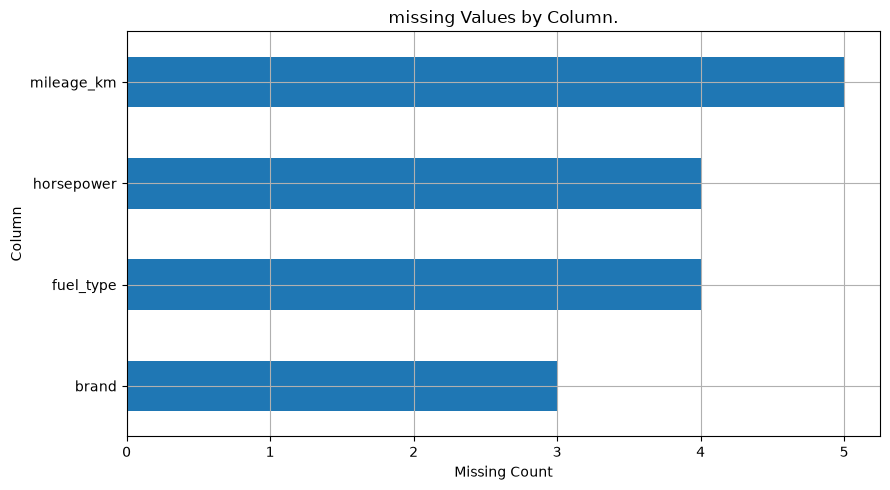

In [431]:
missing_nonzero_1 = missing_values_1[missing_values_1 >0]

if len(missing_nonzero_1)==0:
    print("No missing values.")
else:
    missing_nonzero_1.sort_values().plot(kind="barh")
    plt.title("missing Values by Column.")
    plt.xlabel("Missing Count")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

1.10 Visualize the target distribution

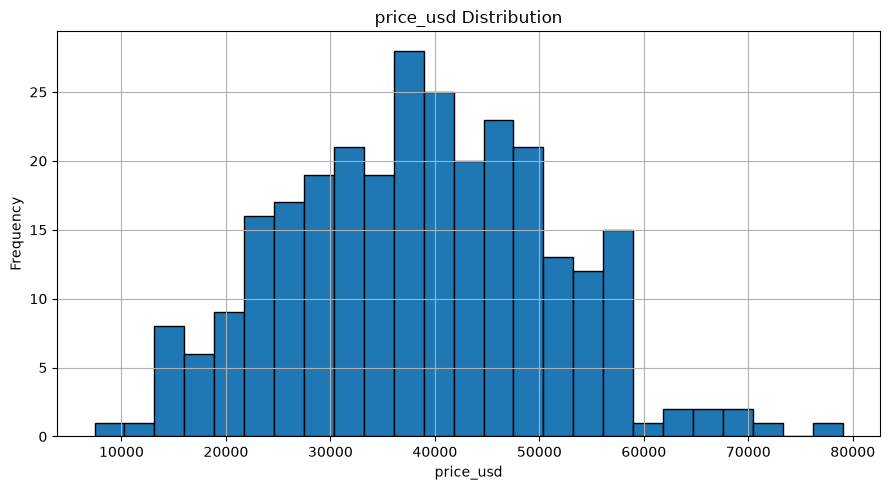

In [432]:
plt.hist(df1["price_usd"].dropna(), bins=25, edgecolor="black")
plt.title("price_usd Distribution")
plt.xlabel("price_usd")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

1.11 Calculate numerical correlations

In [433]:
numeric_eda_1 = df1.select_dtypes(include=np.number).drop(
    columns=["car_id"], errors="ignore"
)
correlation_1 = numeric_eda_1.corr()
display(correlation_1.round(3))

,mileage_km,car_age_years,engine_size_l,horsepower,owners_count,price_usd
mileage_km,1.00,0.92,-0.03,-0.03,0.69,-0.75
car_age_years,0.92,1.00,-0.05,-0.06,0.77,-0.79
engine_size_l,-0.03,-0.05,1.00,0.83,-0.14,0.43
horsepower,-0.03,-0.06,0.83,1.00,-0.12,0.49
owners_count,0.69,0.77,-0.14,-0.12,1.00,-0.69
price_usd,-0.75,-0.79,0.43,0.49,-0.69,1.00


1.12 Visualize the correlation matrix

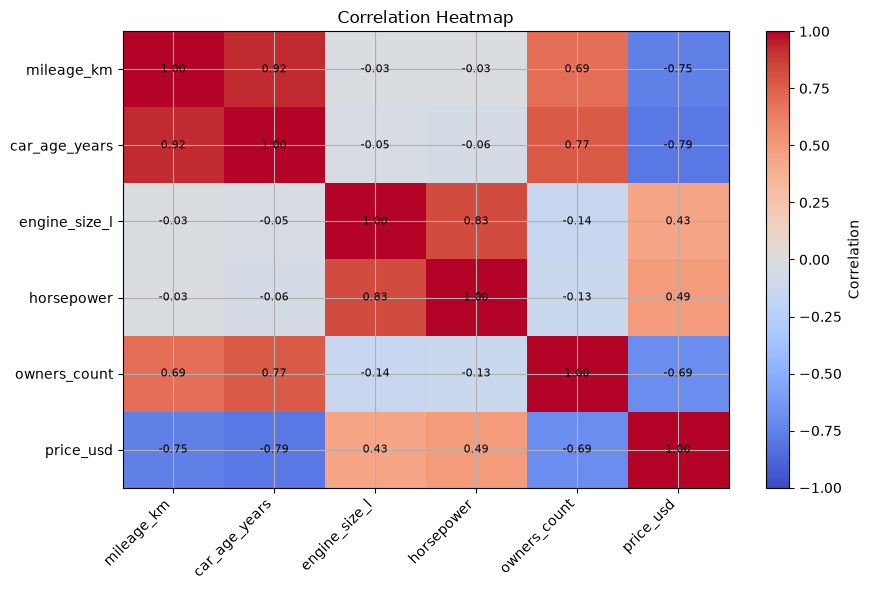

In [434]:
fig, ax = plt.subplots(figsize=(9, 6))
image = ax.imshow(correlation_1, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation_1.columns)))
ax.set_xticklabels(correlation_1.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation_1.index)))
ax.set_yticklabels(correlation_1.index)

for i in range(len(correlation_1.index)):
    for j in range(len(correlation_1.columns)):
        ax.text(j, i, f"{correlation_1.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

plt.colorbar(image, ax=ax, label="Correlation")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

1.13 Plot `mileage_km` against `price_usd`

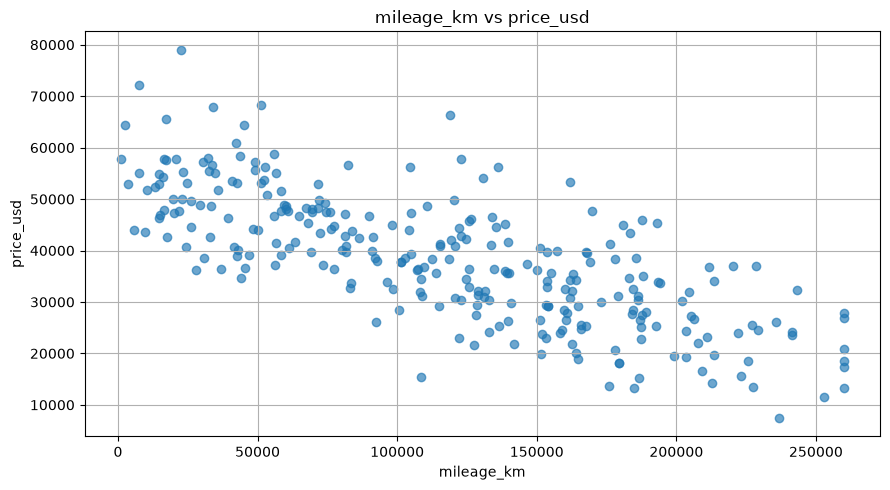

In [435]:
plt.scatter(df1["mileage_km"], df1["price_usd"], alpha=0.65)
plt.title("mileage_km vs price_usd")
plt.xlabel("mileage_km")
plt.ylabel("price_usd")
plt.tight_layout()
plt.show()

1.14 Inspect numeric features with boxplots

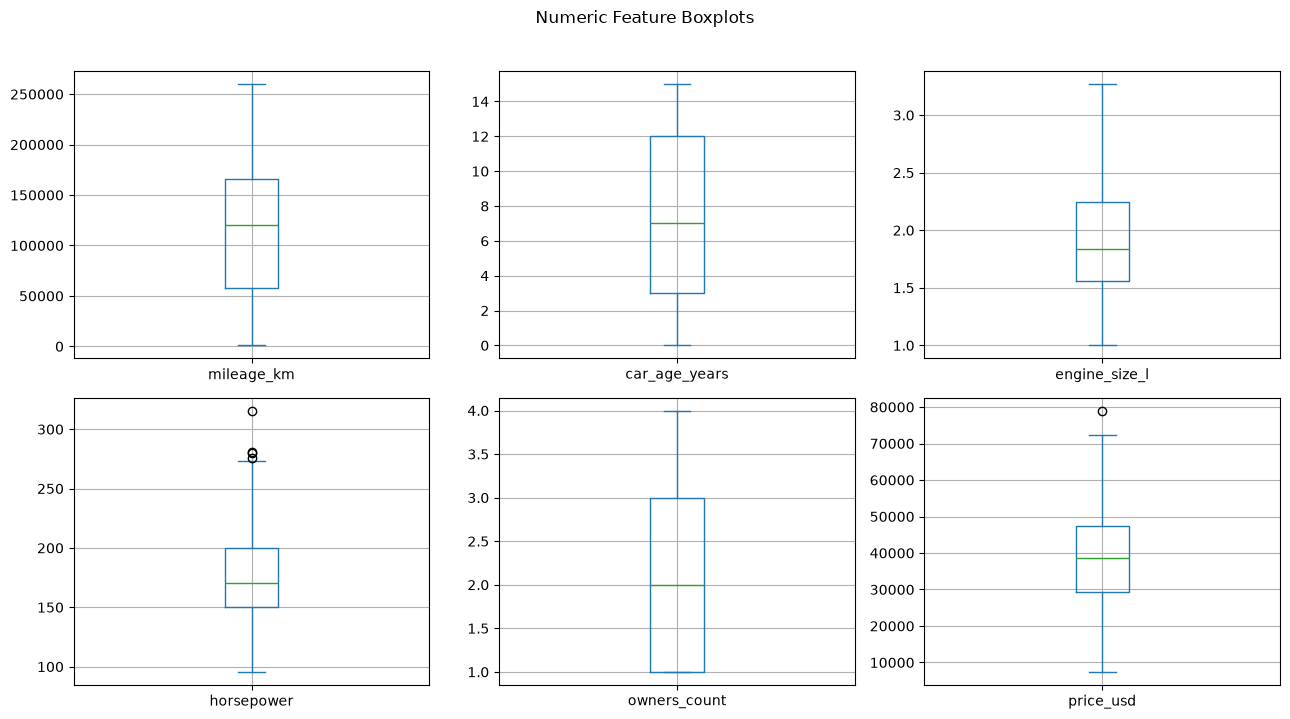

In [436]:
numeric_feature_list_1 = ["mileage_km", "car_age_years", "engine_size_l", "horsepower", "owners_count", "price_usd"]
available_numeric_1 = [
    col for col in numeric_feature_list_1 if col in df1.columns
]

df1[available_numeric_1].plot(
    kind="box",
    subplots=True,
    layout=(math.ceil(len(available_numeric_1) / 3), 3),
    figsize=(13, 3.5 * math.ceil(len(available_numeric_1) / 3)),
    sharex=False,
    sharey=False
)
plt.suptitle("Numeric Feature Boxplots", y=1.02)
plt.tight_layout()
plt.show()

1.15 Inspect categorical feature frequencies

In [437]:
categorical_feature_list_1 = ["transmission"]

for column in categorical_feature_list_1:
    print(f"\nValue counts for {column}:")
    display(df1[column].value_counts(dropna=False).to_frame("count"))


Value counts for transmission:


,count
transmission,
Automatic,185
Manual,98


1.16 Create a clean working copy

In [438]:
df1_clean = df1.copy()

1.17 Remove duplicate rows

In [439]:
rows_before_1 = len(df1_clean)
df1_clean = df1_clean.drop_duplicates().reset_index(drop=True)
rows_after_1 = len(df1_clean)

print("Rows before:", rows_before_1)
print("Rows after:", rows_after_1)
print("Removed duplicates:", rows_before_1 - rows_after_1)

Rows before: 283
Rows after: 280
Removed duplicates: 3


1.18 Define model feature groups

In [440]:
feature_columns_1 = [
    "mileage_km",
    "car_age_years",
    "engine_size_l",
    "horsepower",
    "owners_count",
    "transmission"
]

numeric_features_1 = [
    "mileage_km",
    "car_age_years",
    "engine_size_l",
    "horsepower",
    "owners_count"
]

categorical_features_1 = [
    "transmission"
]

print("All features:", feature_columns_1)
print("Numeric features:", numeric_features_1)
print("Categorical features:", categorical_features_1)

All features: ['mileage_km', 'car_age_years', 'engine_size_l', 'horsepower', 'owners_count', 'transmission']
Numeric features: ['mileage_km', 'car_age_years', 'engine_size_l', 'horsepower', 'owners_count']
Categorical features: ['transmission']


1.19 Define X (features)

In [441]:
X1 = df1.drop(columns=["price_usd"])

display(X1.head())

,car_id,brand,fuel_type,transmission,mileage_km,car_age_years,engine_size_l,horsepower,owners_count
0,CAR0001,Hyundai,Petrol,Automatic,"56,415.00",3,1.47,139.20,2
1,CAR0002,Hyundai,Petrol,Automatic,"154,033.00",11,1.36,163.10,2
2,CAR0003,Toyota,Hybrid,Automatic,"104,558.00",5,1.35,149.50,2
3,CAR0004,Hyundai,Diesel,Manual,"58,516.00",2,1.75,134.90,1
4,CAR0005,Kia,Petrol,Automatic,"101,497.00",7,2.40,221.10,2


1.20 Define y (target)

In [442]:
y1 = df1["price_usd"]
display(y1.head().to_frame("price_usd"))

,price_usd
0,"37,182.35"
1,"29,274.24"
2,"56,221.59"
3,"47,683.85"
4,"37,704.38"


1.21 Split into training and testing sets

In [443]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.20,
    random_state=42
)

1.22 Verify split shapes

In [444]:
print("X_train shape:", X1_train.shape)
print("X_test shape:", X1_test.shape)
print("y_train shape:", y1_train.shape)
print("y_test shape:", y1_test.shape)

X_train shape: (226, 9)
X_test shape: (57, 9)
y_train shape: (226,)
y_test shape: (57,)


1.23 Build the numeric preprocessing pipeline

In [445]:
numeric_pipeline_1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

1.24 Build the categorical preprocessing pipeline

In [446]:
categorical_pipeline_1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

1.25 Combine preprocessing with ColumnTransformer

In [447]:
preprocessor1 = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline_1, numeric_features_1),
        ("categorical", categorical_pipeline_1, categorical_features_1)
    ],
    remainder="drop"
)


1.26 Create the full Linear Regression pipeline

In [448]:
model1 = Pipeline(steps=[
    ("preprocessor", preprocessor1),
    ("regressor", LinearRegression())
])

model1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, d

1.27 Fit the model on training data

In [449]:
model1.fit(X1_train, y1_train)
print("Model training is complete.")

Model training is complete.


1.28 Predict the test data

In [450]:
y1_pred = model1.predict(X1_test)
print("Number of predictions:", len(y1_pred))

Number of predictions: 57


1.29 Compare actual and predicted values

In [451]:
comparison_1 = pd.DataFrame({
    "actual": y1_test.reset_index(drop=True),
    "predicted": pd.Series(y1_pred),
})
comparison_1["absolute_error"] = (
    comparison_1["actual"] - comparison_1["predicted"]
).abs()
display(comparison_1.head(10))

,actual,predicted,absolute_error
0,"55,623.01","58,039.25","2,416.24"
1,"45,960.59","42,396.85","3,563.74"
2,"48,012.44","44,626.97","3,385.47"
3,"31,986.33","35,817.53","3,831.20"
4,"42,759.86","46,123.35","3,363.49"
5,"32,123.45","32,532.32",408.87
6,"47,954.71","46,531.33","1,423.38"
7,"18,613.20","21,137.54","2,524.34"
8,"53,027.01","57,603.89","4,576.88"
9,"49,926.82","50,827.82",901.00


1.30 Calculate Mean Absolute Error (MAE)

In [452]:
mae_1 = mean_absolute_error(y1_test, y1_pred)
print(f"MAE: {mae_1:,.2f}")

MAE: 3,809.87


1.31 Calculate Mean Squared Error (MSE)

In [453]:
mse_1 = mean_squared_error(y1_test, y1_pred)
print(f"MSE: {mse_1:,.2f}")

MSE: 25,553,705.12


1.32 Calculate Root Mean Squared Error (RMSE)

In [454]:
rmse_1 = np.sqrt(mse_1)
print(f"RMSE: {rmse_1:,.2f}")

RMSE: 5,055.07


1.33 Calculate R-squared (R²)

In [455]:
r2_1 = r2_score(y1_test, y1_pred)
print(f"R²: {r2_1:.4f}")

R²: 0.8517


1.34 Plot actual values against predicted values

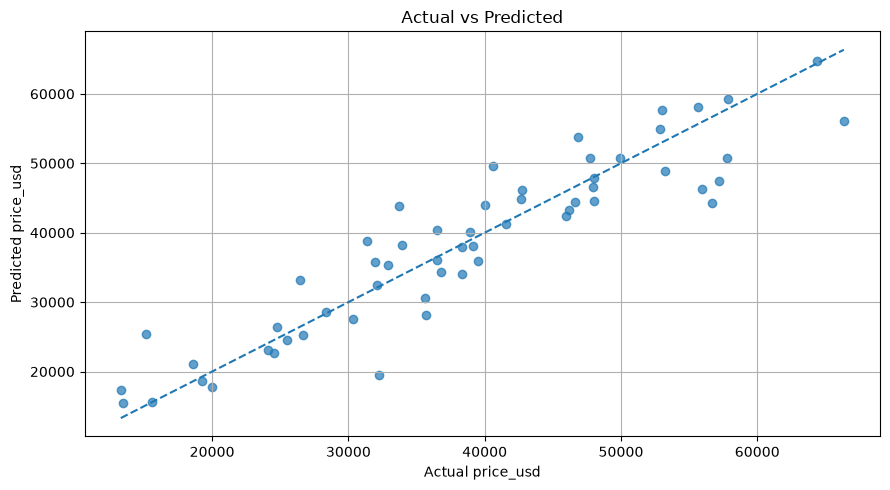

In [456]:
plt.scatter(y1_test, y1_pred, alpha=0.70)
min_value_1 = min(y1_test.min(), y1_pred.min())
max_value_1 = max(y1_test.max(), y1_pred.max())
plt.plot(
    [min_value_1, max_value_1],
    [min_value_1, max_value_1],
    linestyle="--"
)
plt.title("Actual vs Predicted")
plt.xlabel("Actual price_usd")
plt.ylabel("Predicted price_usd")
plt.tight_layout()
plt.show()

1.35 Calculate residuals

In [457]:
residuals1 = y1_test.to_numpy() - y1_pred
residual_table_1 = pd.DataFrame({
    "predicted": y1_pred,
    "residual": residuals1
})
display(residual_table_1.head())

,predicted,residual
0,"58,039.25","-2,416.24"
1,"42,396.85","3,563.74"
2,"44,626.97","3,385.47"
3,"35,817.53","-3,831.20"
4,"46,123.35","-3,363.49"


1.36 Plot residuals against predictions

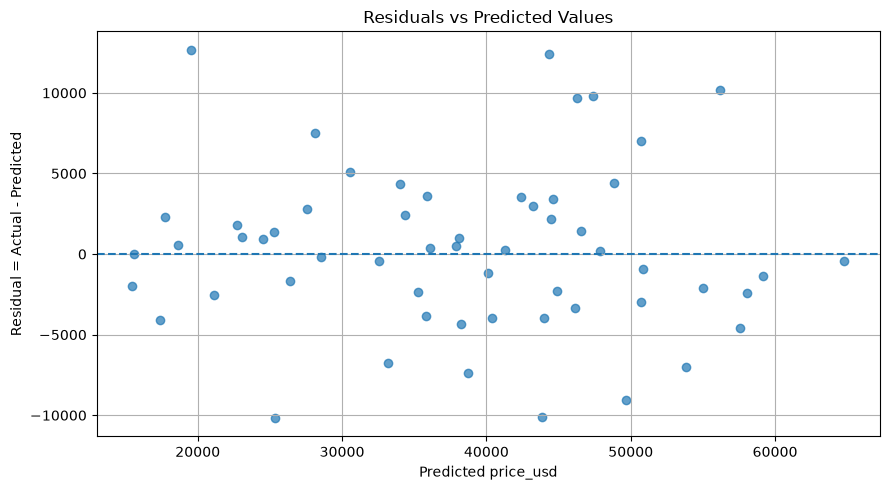

In [458]:
plt.scatter(y1_pred, residuals1, alpha=0.70)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted price_usd")
plt.ylabel("Residual = Actual - Predicted")
plt.tight_layout()
plt.show()

1.37 Visualize the residual distribution

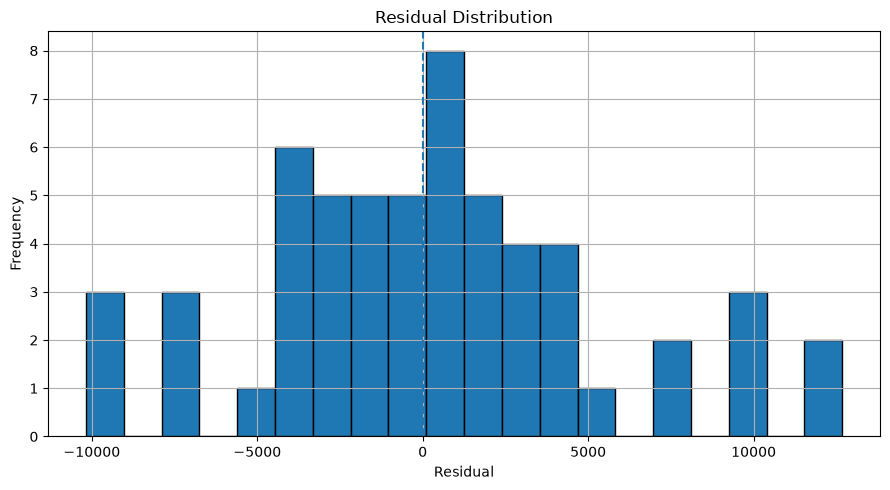

In [459]:
plt.hist(residuals1, bins=20, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

1.38 Extract transformed feature names

In [460]:
transformed_feature_names_1 = (
    model1
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

clean_feature_names_1 = [
    name.split("__", 1)[-1] for name in transformed_feature_names_1
]

print(clean_feature_names_1)

['mileage_km', 'car_age_years', 'engine_size_l', 'horsepower', 'owners_count', 'transmission_Manual']


1.39 Extract and rank model coefficients

In [461]:
coefficients_1 = model1.named_steps["regressor"].coef_

coefficient_table_1 = pd.DataFrame({
    "feature": clean_feature_names_1,
    "coefficient": coefficients_1
})

coefficient_table_1["absolute_coefficient"] = (
    coefficient_table_1["coefficient"].abs()
)

coefficient_table_1 = coefficient_table_1.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(coefficient_table_1)

,feature,coefficient,absolute_coefficient
2,engine_size_l,"2,178.10","2,178.10"
5,transmission_Manual,"-1,745.06","1,745.06"
4,owners_count,"-1,556.06","1,556.06"
1,car_age_years,"-1,423.35","1,423.35"
3,horsepower,111.89,111.89
0,mileage_km,-0.03,0.03


1.40 Display the intercept

In [462]:
intercept_1 = model1.named_steps["regressor"].intercept_
print(f"Intercept: {intercept_1:,.2f}")

Intercept: 33,371.90


1.41 Visualize coefficient magnitude

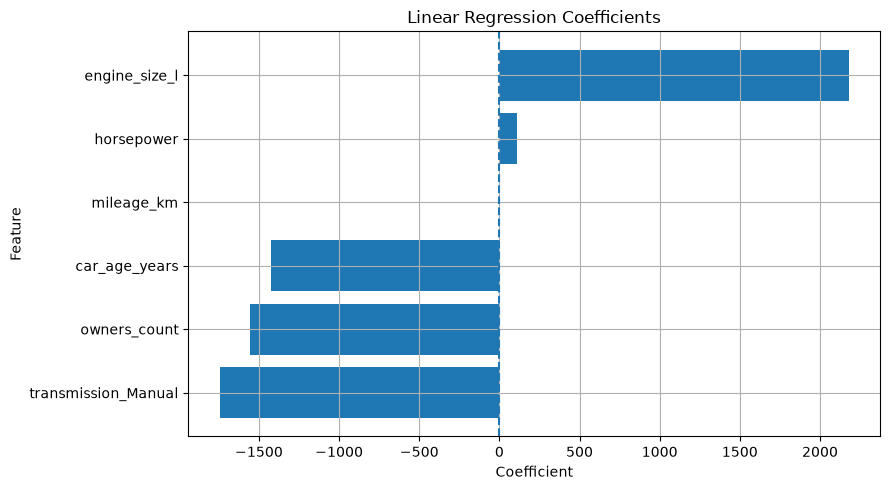

In [463]:
coefficient_plot_1 = coefficient_table_1.sort_values("coefficient")

plt.barh(
    coefficient_plot_1["feature"],
    coefficient_plot_1["coefficient"]
)
plt.axvline(0, linestyle="--")
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

1.42 Predict a new example

In [464]:
new_example_1 = pd.DataFrame([{
    "car_id": 1001,
    "brand": "Toyota",
    "fuel_type": "Petrol",
    "transmission": "Automatic",
    "mileage_km": 50000,
    "car_age_years": 5,
    "engine_size_l": 2.0,
    "horsepower": 170,
    "owners_count": 1
}])

display(new_example_1)

new_prediction_1 = model1.predict(new_example_1)[0]
print(f"Predicted car price (USD): ${new_prediction_1:,.2f}")

,car_id,brand,fuel_type,transmission,mileage_km,car_age_years,engine_size_l,horsepower,owners_count
0,1001,Toyota,Petrol,Automatic,50000,5,2.00,170,1


Predicted car price (USD): $46,388.61


1.43 Save the metrics for final comparison

In [465]:
all_model_results.append({
    "dataset": "Car Price Prediction",
    "MAE": mae_1,
    "MSE": mse_1,
    "RMSE": rmse_1,
    "R2": r2_1
})

print("Metrics saved.")

Metrics saved.
